In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np
from openpmd_viewer import OpenPMDTimeSeries
from scipy.constants import micro, nano, pi

In [2]:
sigmaz = 100 * micro
sigmax = 210 * nano
sigmay = 3.1 * nano
npart = 6.24e9
n0 = npart / (sigmax * sigmay * sigmaz * (2.0 * pi) ** (3.0 / 2.0))

## Visualizing the beams' projections

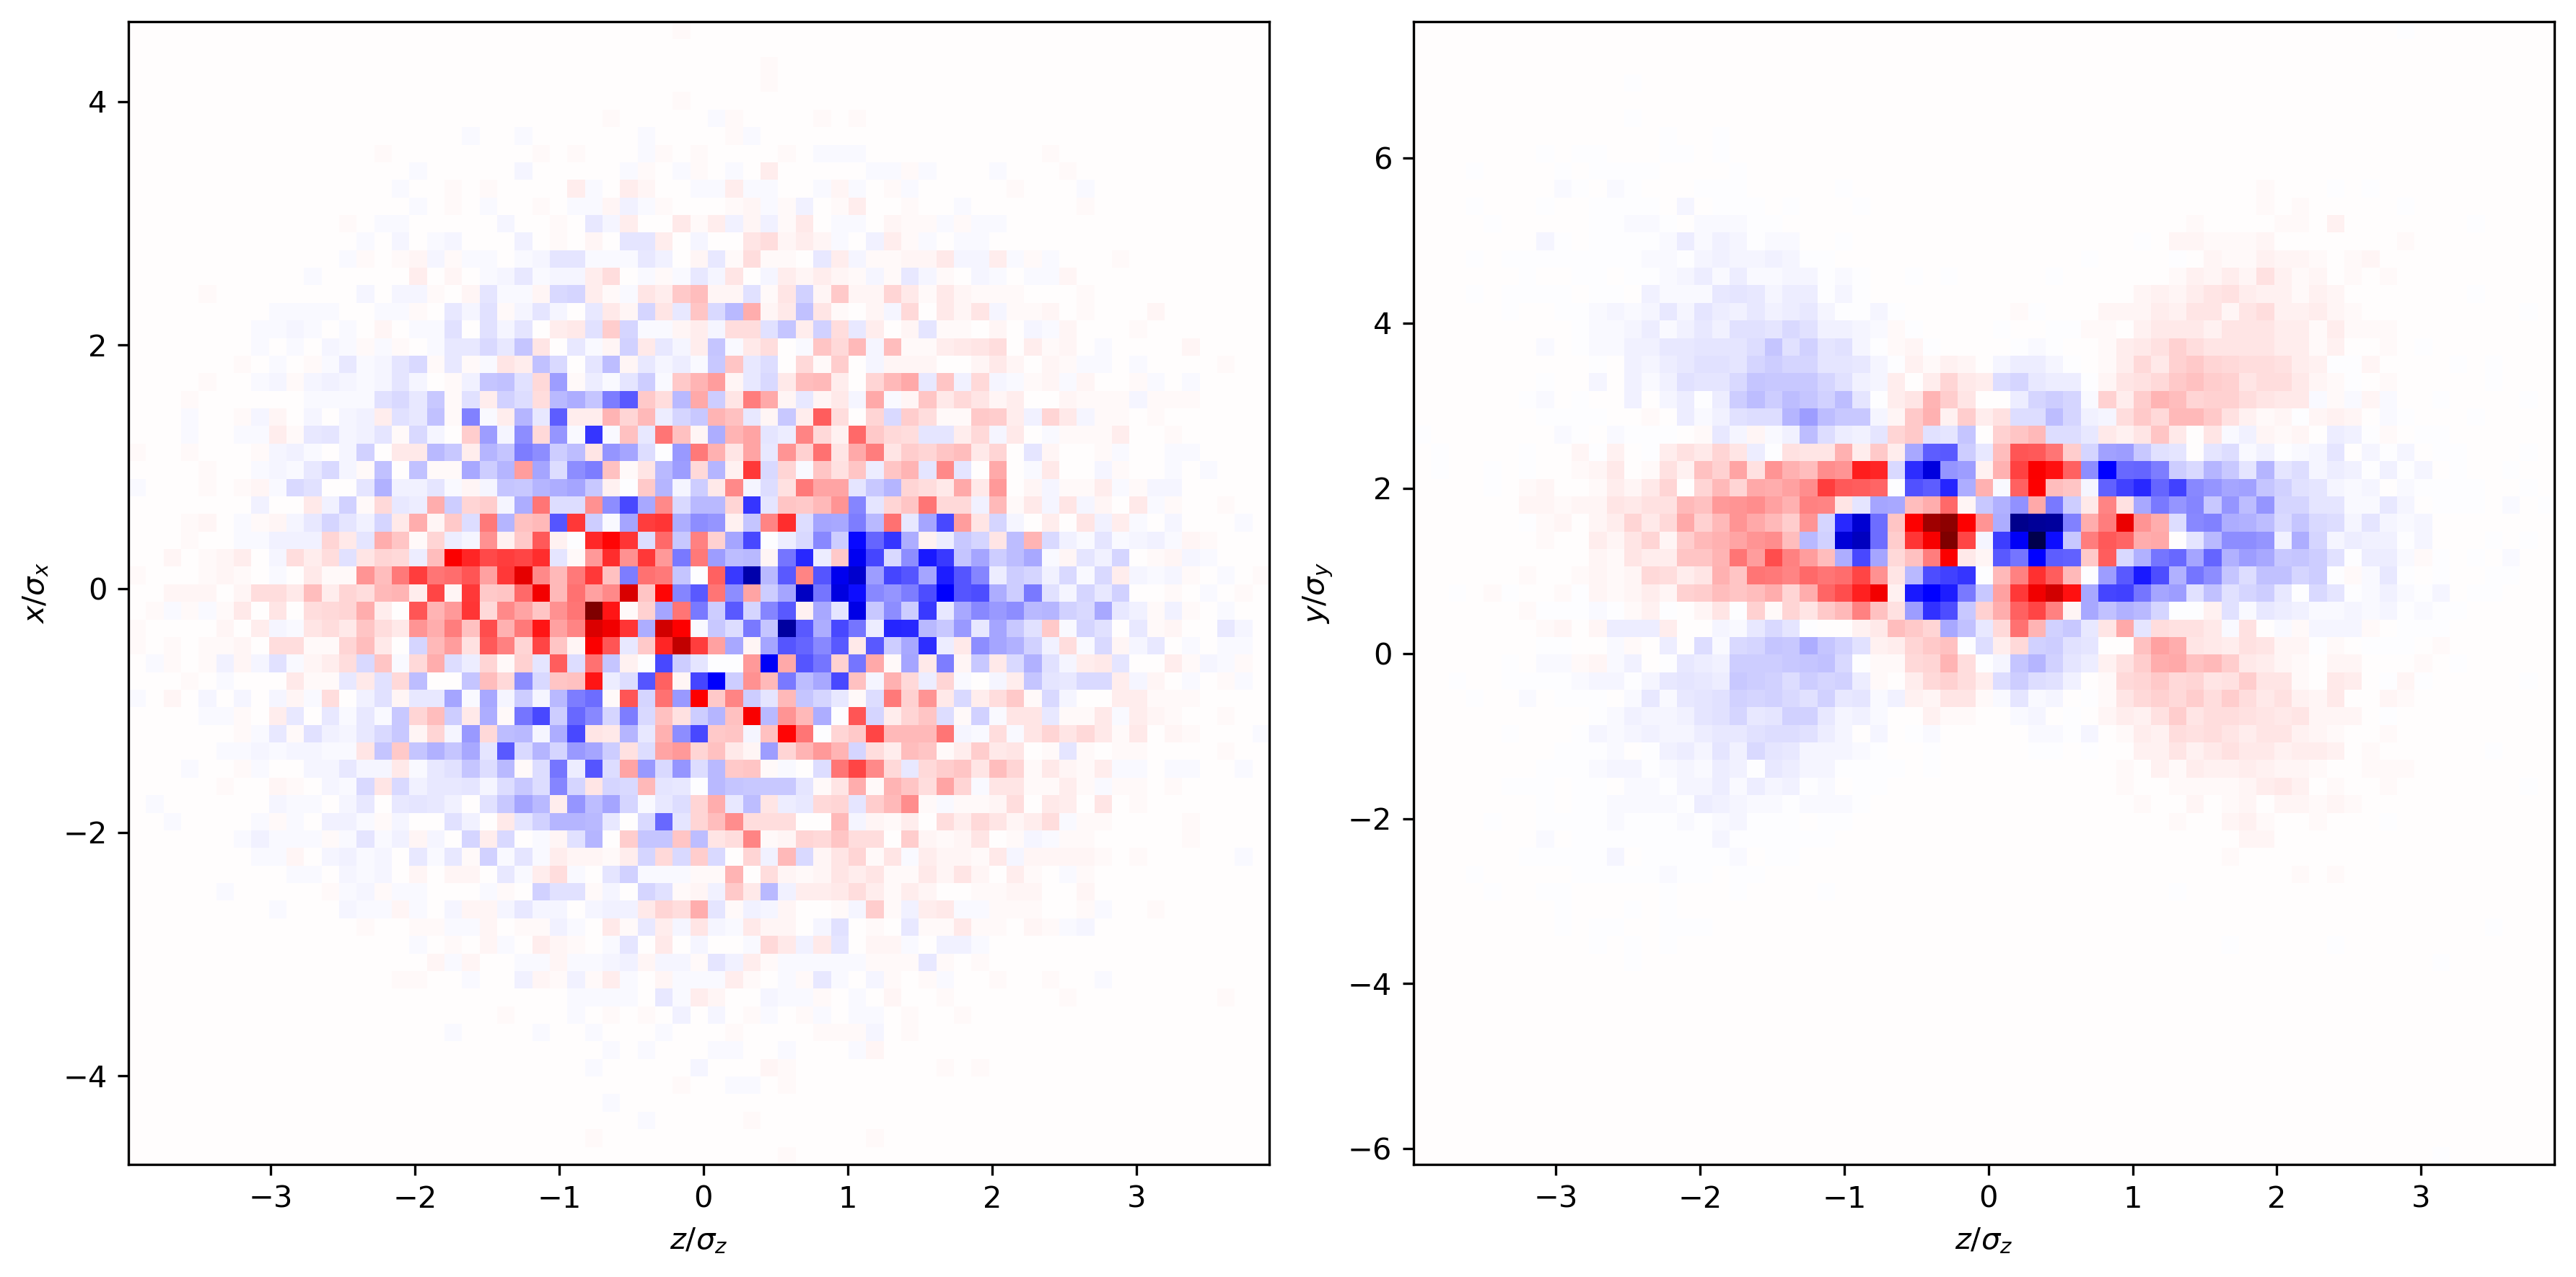

In [3]:
diag_dir = "diags/particles_in"
series = OpenPMDTimeSeries(diag_dir)
iterations = series.iterations
N_steps = len(iterations)

it = iterations[int(0.5 * N_steps)]

x1, y1, z1, w1 = series.get_particle(["x", "y", "z", "w"], species="ele1", iteration=it)
x2, y2, z2, w2 = series.get_particle(["x", "y", "z", "w"], species="pos2", iteration=it)
w1 = -w1
X = np.hstack((x1, x2))
Y = np.hstack((y1, y2))
Z = np.hstack((z1, z2))
W = np.hstack((w1, w2))

H_zx, bx, bz = np.histogram2d(X, Z, bins=(65, 65), weights=W)
H_zy, by, bz = np.histogram2d(Y, Z, bins=(65, 65), weights=W)


extent_zx = [bz[0] / sigmaz, bz[-1] / sigmaz, bx[0] / sigmax, bx[-1] / sigmax]
extent_zy = [bz[0] / sigmaz, bz[-1] / sigmaz, by[0] / sigmay, by[-1] / sigmay]

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12, 6), dpi=300)

ax[0].imshow(
    H_zx,
    extent=extent_zx,
    cmap="seismic",
    vmin=-H_zx.max(),
    vmax=H_zx.max(),
    aspect="auto",
)
ax[1].imshow(
    H_zy,
    extent=extent_zy,
    cmap="seismic",
    vmin=-H_zy.max(),
    vmax=H_zy.max(),
    aspect="auto",
)

ax[0].set_xlabel(r"$z/\sigma_z$")
ax[1].set_xlabel(r"$z/\sigma_z$")

ax[0].set_ylabel(r"$x/\sigma_x$")
ax[1].set_ylabel(r"$y/\sigma_y$")

fig.tight_layout()
plt.show()

## Luminosity distribution

In [4]:
def extract_Ecom_and_dLdE(filename):
    """
    Return 2 numpy arrays:
    - the center-of-mass energy (in eV)
    - the luminosity spectrum (in m^-2.eV^-1)
    """
    with open(filename) as f:
        # First line: header, contains the energies
        line = f.readline()
        E_com = np.array(list(map(float, re.findall("=(.*?)\\(", line))))
    data = np.loadtxt(filename)
    dLdE = data[1, 2:]  # Read the second line

    return E_com, dLdE

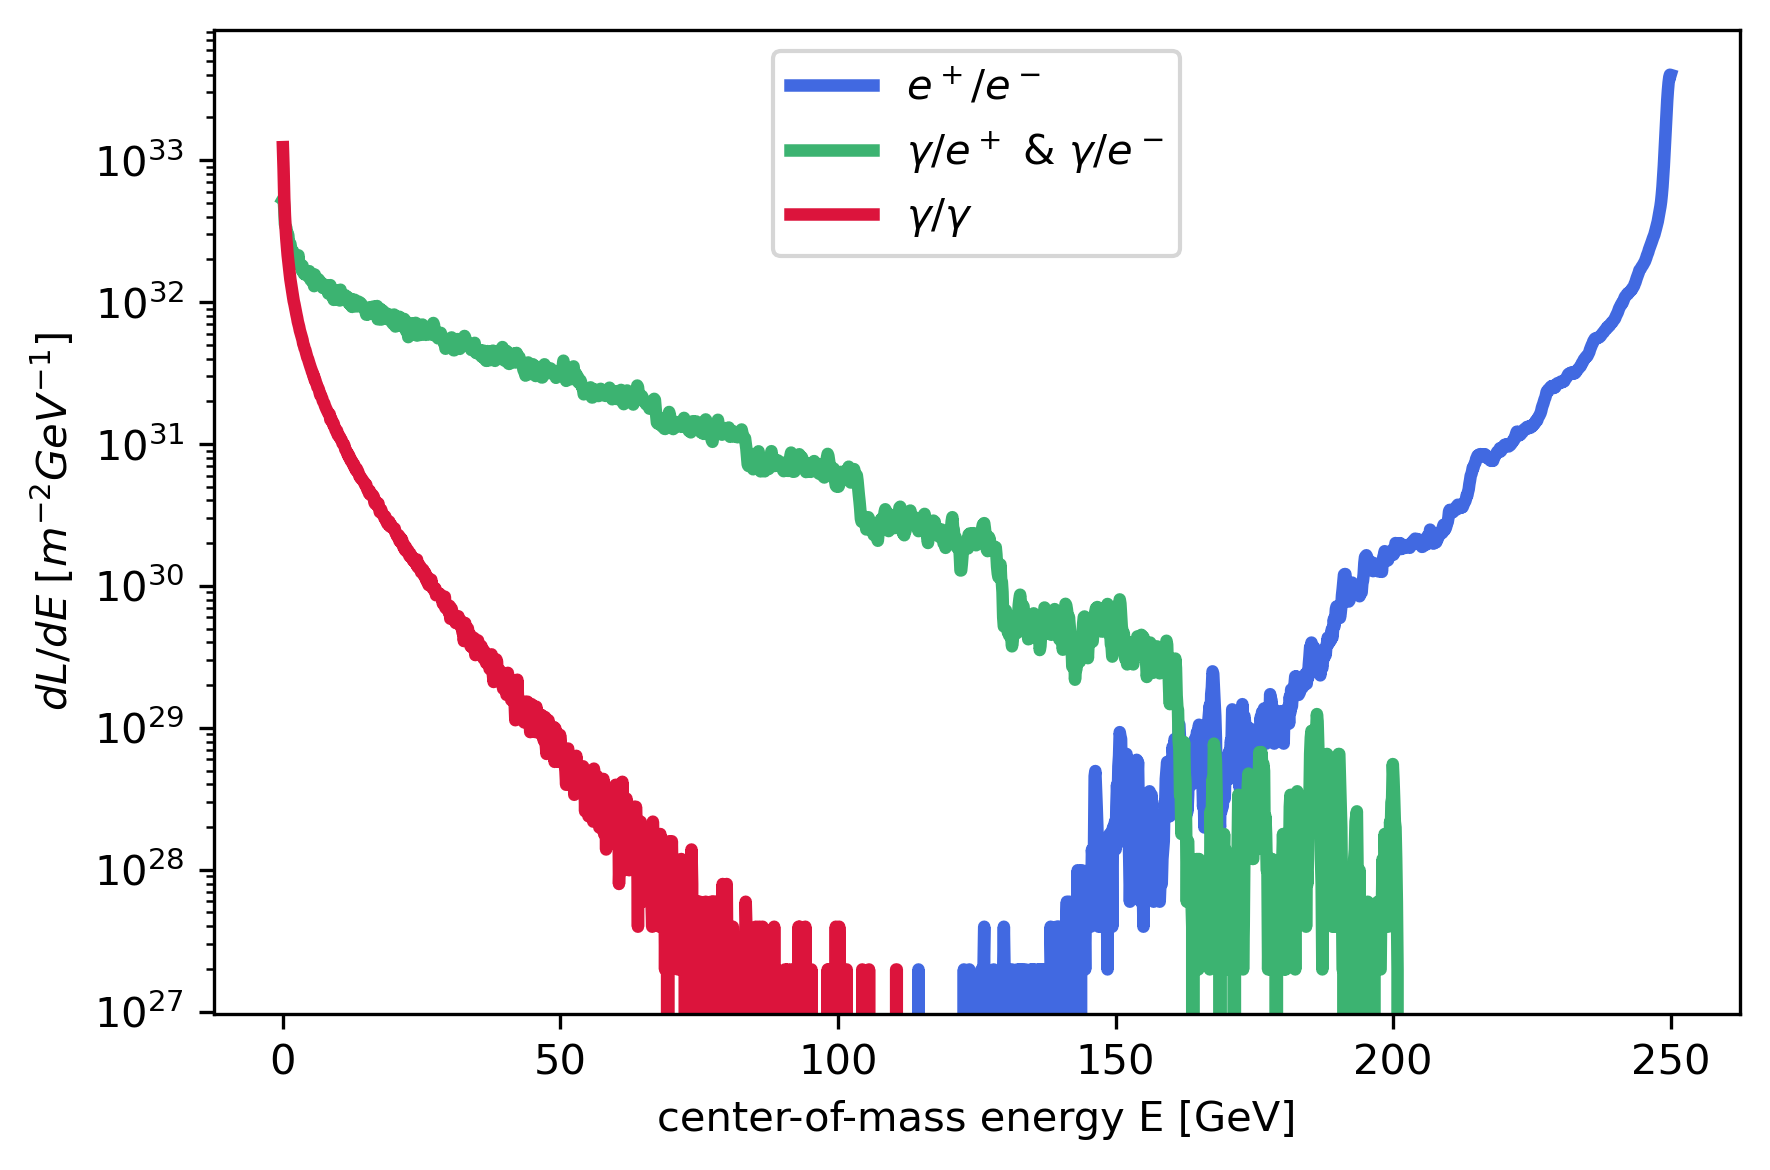

In [5]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 4), dpi=300)

sim_folder = "."

# Electron-positron luminosity
E_com, dLdE_ep1 = extract_Ecom_and_dLdE(
    sim_folder + "/diags/reducedfiles/DiffLumi_ele1_pos2.txt"
)
E_com, dLdE_ep2 = extract_Ecom_and_dLdE(
    sim_folder + "/diags/reducedfiles/DiffLumi_pos1_ele2.txt"
)
dLdE_ep = dLdE_ep1 + dLdE_ep2
ax.semilogy(
    1e-9 * E_com, 1e9 * dLdE_ep, label="$e^+/e^-$", color="royalblue", lw=3
)  # convert from eV to GeV

# Photon-lepton luminosity
E_com, dLdE_gl1 = extract_Ecom_and_dLdE(
    sim_folder + "/diags/reducedfiles/DiffLumi_pho1_ele2.txt"
)
E_com, dLdE_gl2 = extract_Ecom_and_dLdE(
    sim_folder + "/diags/reducedfiles/DiffLumi_pho1_pos2.txt"
)
E_com, dLdE_gl3 = extract_Ecom_and_dLdE(
    sim_folder + "/diags/reducedfiles/DiffLumi_ele1_pho2.txt"
)
E_com, dLdE_gl4 = extract_Ecom_and_dLdE(
    sim_folder + "/diags/reducedfiles/DiffLumi_pos1_pho2.txt"
)
dLdE_gl = dLdE_gl1 + dLdE_gl2 + dLdE_gl3 + dLdE_gl4
ax.semilogy(
    1e-9 * E_com,
    1e9 * dLdE_gl,
    label=r"$\gamma/e^+$ & $\gamma/e^-$",
    color="mediumseagreen",
    lw=3,
)

# Photon-photon
E_com, dLdE_gg = extract_Ecom_and_dLdE(
    sim_folder + "/diags/reducedfiles/DiffLumi_pho1_pho2.txt"
)
ax.semilogy(
    1e-9 * E_com, 1e9 * dLdE_gg, label=r"$\gamma/\gamma$", color="crimson", lw=3
)

ax.legend(loc=0)
ax.set_ylabel(r"$dL/dE \; [m^{-2} GeV^{-1}$]")
ax.set_xlabel("center-of-mass energy E [GeV]")
fig.tight_layout()
plt.show()